In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from pandas.api import types as pdt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [2]:
from typing import Tuple, Literal

In [3]:
def goto_root_dir(root_name):
    current = os.getcwd()
    while True:
        if os.path.basename(current) == root_name:
            os.chdir(current)
            print(f"Changed working directory to: {current}")
            break
        parent = os.path.dirname(current)
        if parent == current:
            raise FileNotFoundError(f"Root directory '{root_name}' not found.")
        current = parent

goto_root_dir("llm-prep")

Changed working directory to: d:\MyFolder\Lab\llm-prep


# Dataset: German Credit

### 1. Load dataset

In [3]:
data_path = os.path.join('datasets', 'raw', 'experiment', 'GermanCredit', 'german.data')
data_df = pd.read_csv(data_path, sep='\s+', header=None)
data_df.columns = [
    'Status', 'Duration', 'CreditHistory', 'Purpose', 'CreditAmount', 'Savings',
    'EmploymentDuration', 'InstallmentRate', 'PersonalStatusSex', 'OtherDebtors',
    'ResidenceDuration', 'Property', 'Age', 'OtherInstallmentPlans', 'Housing',
    'NumberExistingCredits', 'Job', 'NumberPeopleMaintenance', 'Telephone',
    'ForeignWorker', 'Target'
]
data_df['Target'] = data_df['Target'].map({1: 0, 2: 1})  # 1: good, 2: bad
data_df.head()

,Status,Duration,CreditHistory,Purpose,CreditAmount,Savings,EmploymentDuration,InstallmentRate,PersonalStatusSex,OtherDebtors,...,Property,Age,OtherInstallmentPlans,Housing,NumberExistingCredits,Job,NumberPeopleMaintenance,Telephone,ForeignWorker,Target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


In [4]:
symbol_mapping = {
    'Status': {
        'A11': '< 0 DM', 
        'A12': '0 <= ... < 200 DM', 
        'A13': '>= 200 DM or salary assignments >= 1 year',
        'A14': 'no checking account',
    },
    'CreditHistory': {
        'A30': 'no credits taken / all credits paid back duly',
        'A31': 'all credits at this bank paid back duly',
        'A32': 'existing credits paid back duly till now',
        'A33': 'delay in paying off in the past',
        'A34': 'critical account / other credits existing (not at this bank)',
    },
    'Purpose': {
        'A40': 'car (new)',
        'A41': 'car (used)',
        'A42': 'furniture/equipment', 
        'A43': 'radio/television',
        'A44': 'domestic appliances',
        'A45': 'repairs',
        'A46': 'education',
        'A47': 'vacation (does not exist?)',
        'A48': 'retraining',
        'A49': 'business',
        'A410': 'others',
    },
    'Savings': {
        'A61': '< 100 DM',
        'A62': '100 <= ... < 500 DM',
        'A63': '500 <= ... < 1000 DM',
        'A64': '>= 1000 DM',
        'A65': 'unknown / no savings account',
    },
    'EmploymentDuration': {
        'A71': 'unemployed',
        'A72': '< 1 year',
        'A73': '1 <= ... < 4 years',
        'A74': '4 <= ... < 7 years',
        'A75': '>= 7 years',
    },
    'PersonalStatusSex': {
        'A91': 'male: divorced/separated',
        'A92': 'female: divorced/separated/married',
        'A93': 'male: single',
        'A94': 'male: married/widowed',
        'A95': 'female: single',
    },
    'OtherDebtors': {
        'A101': 'none',
        'A102': 'co-applicant',
        'A103': 'guarantor',
    },
    'Property': {
        'A121': 'real estate',
        'A122': 'building society savings agreement / life insurance',
        'A123': 'car or other, not in attribute 6',
        'A124': 'unknown / no property',
    },
    'OtherInstallmentPlans': {
        'A141': 'bank',
        'A142': 'stores',
        'A143': 'none',
    },
    'Housing': {
        'A151': 'rent',
        'A152': 'own',
        'A153': 'for free',
    },
    'Job': {
        'A171': 'unemployed/unskilled - non-resident',
        'A172': 'unskilled - resident',
        'A173': 'skilled employee / official',
        'A174': 'management/self-employed/highly qualified employee/officer',
    },
    'Telephone': {
        'A191': 'none',
        'A192': 'yes, registered under the customer\'s name',
    },
    'ForeignWorker': {
        'A201': 'yes',
        'A202': 'no'
    }
}

for col, mapping in symbol_mapping.items():
    data_df[col] = data_df[col].map(mapping)

data_df.head()

,Status,Duration,CreditHistory,Purpose,CreditAmount,Savings,EmploymentDuration,InstallmentRate,PersonalStatusSex,OtherDebtors,...,Property,Age,OtherInstallmentPlans,Housing,NumberExistingCredits,Job,NumberPeopleMaintenance,Telephone,ForeignWorker,Target
0,< 0 DM,6,critical account / other credits existing (not...,radio/television,1169,unknown / no savings account,>= 7 years,4,male: single,none,...,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customer's name",yes,0
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,radio/television,5951,< 100 DM,1 <= ... < 4 years,2,female: divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee / official,1,none,yes,1
2,no checking account,12,critical account / other credits existing (not...,education,2096,< 100 DM,4 <= ... < 7 years,2,male: single,none,...,real estate,49,none,own,1,unskilled - resident,2,none,yes,0
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,< 100 DM,4 <= ... < 7 years,2,male: single,guarantor,...,building society savings agreement / life insu...,45,none,for free,1,skilled employee / official,2,none,yes,0
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1 <= ... < 4 years,3,male: single,none,...,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes,1


In [5]:
feature_summary = pd.DataFrame({
    'Feature': data_df.columns,
    'Type': [
        'binary' if pd.api.types.is_object_dtype(data_df[col]) and data_df[col].nunique() == 2 else
        'categorical' if pd.api.types.is_object_dtype(data_df[col]) else 
        'numerical'
        for col in data_df.columns
    ],
    'Unique values': [data_df[col].nunique() for col in data_df.columns]
})

feature_summary

,Feature,Type,Unique values
0,Status,categorical,4
1,Duration,numerical,33
2,CreditHistory,categorical,5
3,Purpose,categorical,10
4,CreditAmount,numerical,921
5,Savings,categorical,5
6,EmploymentDuration,categorical,5
7,InstallmentRate,numerical,4
8,PersonalStatusSex,categorical,4
9,OtherDebtors,categorical,3


In [6]:
feature_summary[feature_summary['Type'] == 'categorical'].sort_values(by='Unique values', ascending=False)

,Feature,Type,Unique values
3,Purpose,categorical,10
2,CreditHistory,categorical,5
5,Savings,categorical,5
6,EmploymentDuration,categorical,5
0,Status,categorical,4
8,PersonalStatusSex,categorical,4
11,Property,categorical,4
16,Job,categorical,4
9,OtherDebtors,categorical,3
13,OtherInstallmentPlans,categorical,3


In [7]:
feature_summary[feature_summary['Type'] == 'binary']

,Feature,Type,Unique values
18,Telephone,binary,2
19,ForeignWorker,binary,2


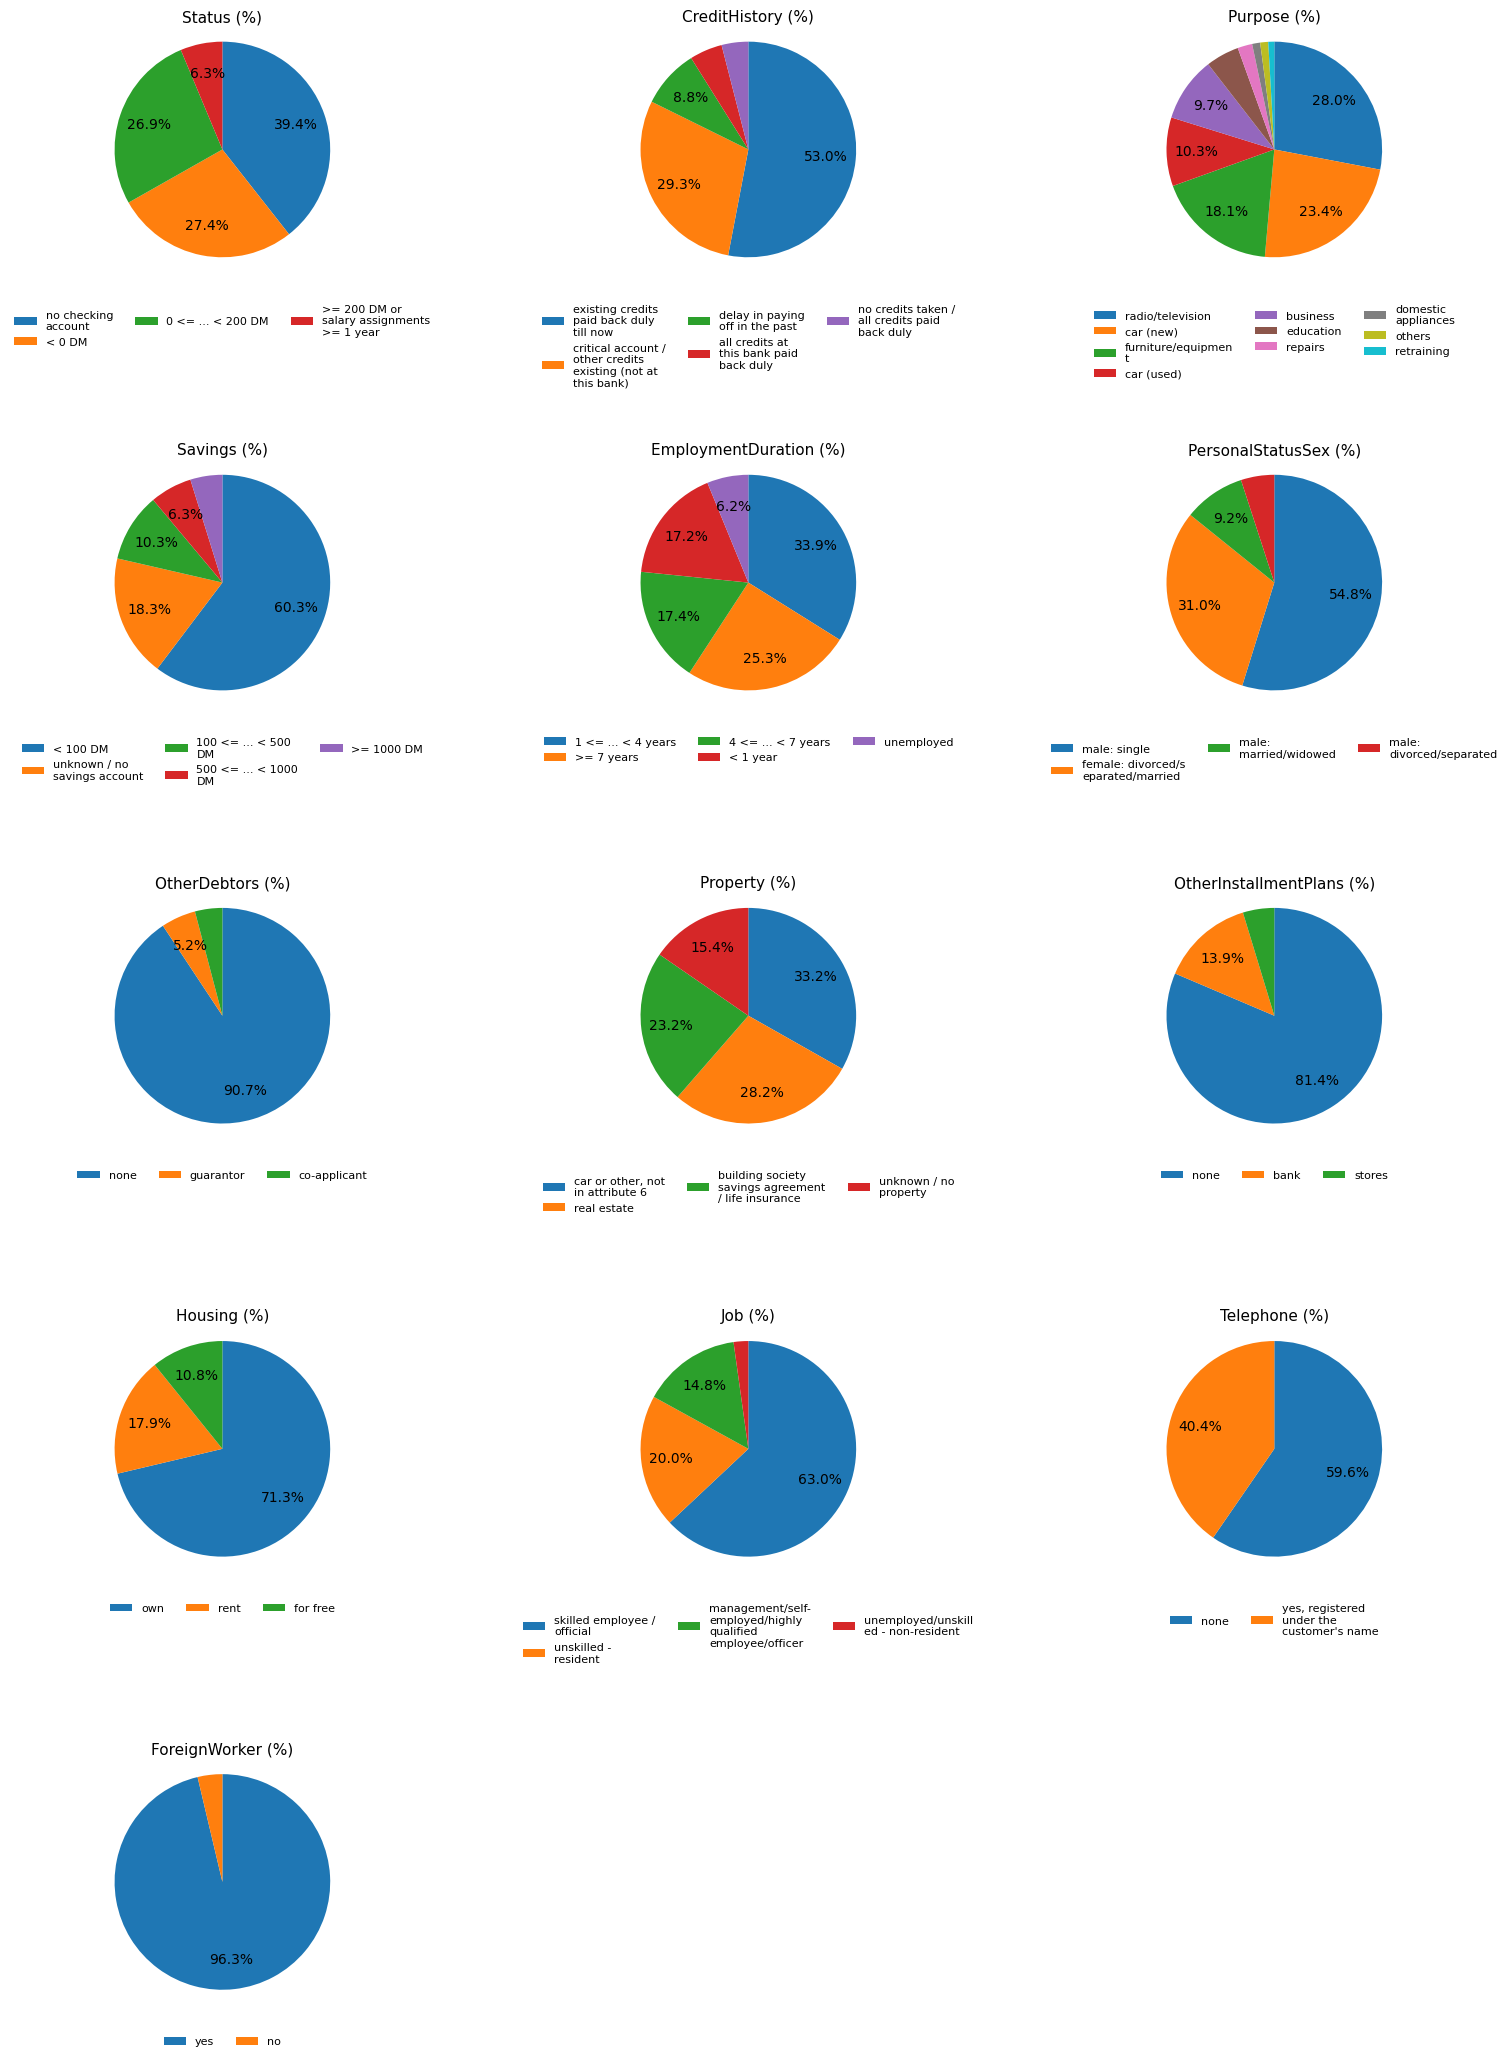

In [15]:
from textwrap import fill

def autopct_hide_small(pct):
    """Hide percentage numbers for slices smaller than 5%"""
    return f'{pct:.1f}%' if pct > 5 else ''

# def top_k_with_other(s, k=8):
#     """Keep top-k categories; group the rest into 'Other'."""
#     if len(s) <= k:
#         return s
#     top = s.iloc[:k]
#     other = s.iloc[k:].sum()
#     return pd.concat([top, pd.Series({'Other': other})])

def wrap_labels(labels, w=18):
    return [fill(str(lbl), w) for lbl in labels]


def plot_categorical_pies(
    df: pd.DataFrame,
    cols_per_row: int = 3,
):
    categorical_features = [
        c for c in data_df.columns
        if pd.api.types.is_object_dtype(data_df[c]) or isinstance(data_df[c].dtype, pd.CategoricalDtype)
    ]

    n = len(categorical_features)
    rows = max(1, (n + cols_per_row - 1) // cols_per_row)

    fig, axes = plt.subplots(
        rows, cols_per_row, figsize=(cols_per_row * 6.2, rows * 5.0),  
        squeeze=False, constrained_layout=False
    )
    axes = axes.ravel()

    for i, col in enumerate(categorical_features):
        vc = (data_df[col].astype('string').fillna('NaN')
            .value_counts(normalize=True, dropna=False) * 100)
        # vc = top_k_with_other(vc, k=8)

        wedges, _, _ = axes[i].pie(
            vc.values,
            startangle=90,
            counterclock=False,
            autopct=autopct_hide_small,
            pctdistance=0.72,
            radius=1.4,
            textprops={'fontsize': 10}
        )
        axes[i].set_aspect('equal')
        axes[i].set_title(f'{col} (%)', fontsize=11, pad=23)

        # legend BELOW each pie; wrapped labels; multiple columns
        axes[i].legend(
            wedges, wrap_labels(vc.index.tolist(), w=18),
            loc='upper center',
            bbox_to_anchor=(0.5, -0.28),     # push legend further down
            ncol=3,                          # spread labels horizontally
            fontsize=8,
            frameon=False,
            borderaxespad=0.0
        )

    # hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    # extra vertical space between rows so legends don't touch the next row
    plt.subplots_adjust(wspace=0.35, hspace=1.25)
    plt.show()


plot_categorical_pies(data_df, cols_per_row=3)


In [9]:
feature_summary[feature_summary['Type'] == 'numerical'].sort_values(by='Unique values', ascending=False)

,Feature,Type,Unique values
4,CreditAmount,numerical,921
12,Age,numerical,53
1,Duration,numerical,33
7,InstallmentRate,numerical,4
10,ResidenceDuration,numerical,4
15,NumberExistingCredits,numerical,4
17,NumberPeopleMaintenance,numerical,2
20,Target,numerical,2


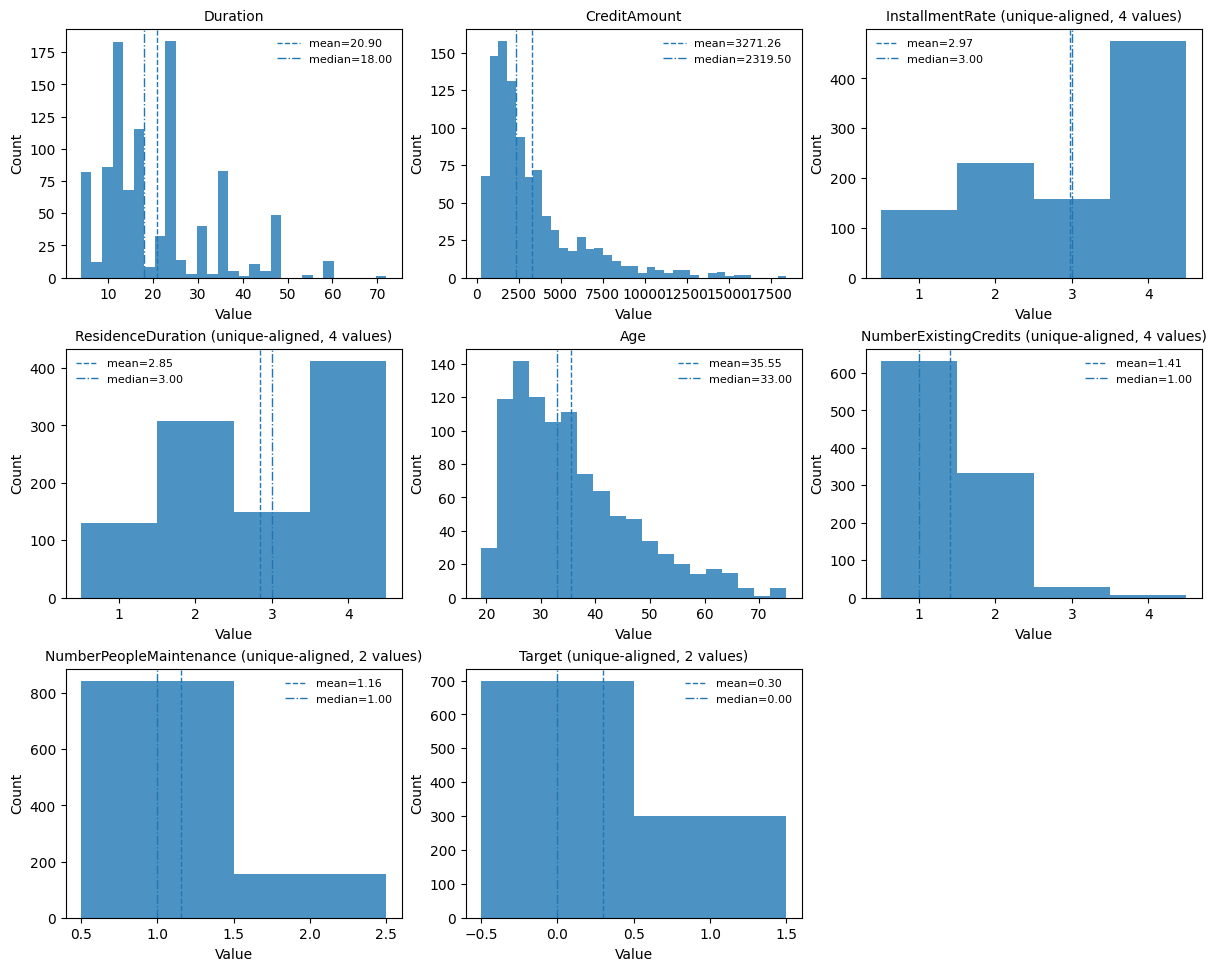

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _edges_from_unique(s: pd.Series):
    """Return histogram bin edges aligned to the sorted unique values in s.
    Works for integer or float discrete values.
    """
    u = np.array(sorted(pd.unique(s)))
    if len(u) == 1:
        # single bin centered at the value
        return np.array([u[0] - 0.5, u[0] + 0.5])
    mids = (u[1:] + u[:-1]) / 2.0
    # extrapolate lower/upper edges by half a gap
    left  = u[0]  - (mids[0] - u[0])
    right = u[-1] + (u[-1] - mids[-1])
    return np.concatenate(([left], mids, [right]))

def plot_numeric_histograms(
    df: pd.DataFrame,
    cols_per_row: int = 3,
    discrete_threshold: int = 10,  # treat as discrete if nunique ≤ threshold
    bins_continuous: int | str = "auto",
    show_stats: bool | bool = True,
    figsize_per_plot=(4, 3.2),
    alpha: float = 0.8
):
    num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    if not num_cols:
        raise ValueError("No numeric columns found.")

    n = len(num_cols)
    rows = (n + cols_per_row - 1) // cols_per_row
    fig, axes = plt.subplots(
        rows, cols_per_row,
        figsize=(figsize_per_plot[0]*cols_per_row, figsize_per_plot[1]*rows),
        constrained_layout=True
    )
    axes = np.atleast_1d(axes).ravel()

    for i, col in enumerate(num_cols):
        s = pd.to_numeric(df[col], errors="coerce").dropna()
        ax = axes[i]

        if len(s) == 0:
            ax.set_title(f"{col} (no data)"); ax.axis("off"); continue

        nunq = s.nunique()

        if nunq <= discrete_threshold:
            # Align edges exactly to the unique values
            edges = _edges_from_unique(s)
            ax.hist(s, bins=edges, alpha=alpha)
            ax.set_title(f"{col} (unique-aligned, {nunq} values)", fontsize=10)
        else:
            # Continuous fallback
            ax.hist(s, bins=bins_continuous, alpha=alpha)
            ax.set_title(col, fontsize=10)

        ax.set_xlabel("Value")
        ax.set_ylabel("Count")

        if show_stats and len(s) > 0:
            mean = s.mean()
            med  = s.median()
            ax.axvline(mean, linestyle="--", linewidth=1)
            ax.axvline(med,  linestyle="-.", linewidth=1)
            ax.legend([f"mean={mean:.2f}", f"median={med:.2f}"],
                      fontsize=8, frameon=False)

    # hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.show()

plot_numeric_histograms(data_df, cols_per_row=3, discrete_threshold=10)


Features chosen to inject missingness (based on types, number & distribution of unique values):
- Categorical: `Purpose` (10), `CreditHistory` (5)
- Binary: `Telephone` (balanced), `ForeignWorker`(unbalanced)
- Numerical: `CreditAmount` (921), `Age` (53), `Duration` (33)

### 2. Split train/test sets

In [7]:
X = data_df.drop(columns=['Target'])
y = data_df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.125, random_state=42, stratify=y_train) # Validation set size: 0.125 * 0.8 = 0.1 (10% of total)

train_set = pd.concat([X_train, y_train], axis=1)
valid_set = pd.concat([X_val, y_val], axis=1)
test_set = pd.concat([X_test, y_test], axis=1)

os.makedirs(os.path.join('datasets', 'processed', 'experiment', 'GermanCredit', 'full'), exist_ok=True)
train_set.to_csv(os.path.join('datasets', 'processed', 'experiment', 'GermanCredit', 'full', 'train.csv'), index=False)
valid_set.to_csv(os.path.join('datasets', 'processed', 'experiment', 'GermanCredit', 'full', 'valid.csv'), index=False)
test_set.to_csv(os.path.join('datasets', 'processed', 'experiment', 'GermanCredit', 'full', 'test.csv'), index=False)

### 3. Inject missingness

In [29]:
train_df = pd.read_csv(os.path.join('datasets', 'processed', 'experiment', 'GermanCredit', 'full', 'train.csv'))
valid_df = pd.read_csv(os.path.join('datasets', 'processed', 'experiment', 'GermanCredit', 'full', 'valid.csv'))
test_df = pd.read_csv(os.path.join('datasets', 'processed', 'experiment', 'GermanCredit', 'full', 'test.csv'))

In [31]:
cols_to_inject = ('Purpose', 'CreditHistory', 'Telephone', 'ForeignWorker', 'CreditAmount', 'Age', 'Duration')

10%

In [33]:
def inject_missingness(
    df: pd.DataFrame,
    frac: float = 0.10,
    method: str = "fixed",                 # "fixed" (exact count) or "bernoulli" (per-row probability)
    include: tuple = tuple(),              # columns to include
    exclude: tuple = tuple(),              # columns to skip
    random_state: int | None = None,
    ensure_observed: bool = True,          # keep at least one observed value per column
    stratify_within_col: bool = True,      # balance missingness across each column's own categories (when categorical-like)
    max_unique_for_stratify: int = 100     # skip within-column stratification for very high-cardinality columns
) -> pd.DataFrame:
    """
    Inject MCAR missing values independently per column.

    Behavior
    --------
    * Applies the same missing fraction `frac` to each column independently (unless excluded).
    * If `stratify_within_col=True` and the column is categorical-like with <= max_unique_for_stratify
      distinct observed values, the same fraction is masked *within each level* (preserving proportions).
      Otherwise it falls back to global random masking within that column.
    * Only currently observed (non-NaN) cells are candidates for masking.
    * With `ensure_observed=True`, at least one value remains observed in every processed column.

    Parameters
    ----------
    df : pd.DataFrame
    frac : float
        Fraction of *currently observed* values to mask per column. Must be in (0, 1).
    method : {"fixed","bernoulli"}
        "fixed": mask exactly round(frac * n_obs) entries per column/group.
        "bernoulli": mask each observed entry independently with probability = frac.
    include : tuple
        Column names to include. In this case, assume only the columns listed in this tuple are used. If use this parameter, do not use `exclude`.
    exclude : tuple
        Column names not to mask. In this case, assume all columns are used except those listed in this tuple. If use this parameter, do not use `include`.
    random_state : int | None
        Seed for reproducibility (NumPy Generator).
    ensure_observed : bool
        Ensure at least one non-missing value remains in each masked column.
    stratify_within_col : bool
        If True, balance missingness across each column's own categories (categorical-like only).
    max_unique_for_stratify : int
        Upper bound on unique values to still attempt within-column stratification.

    Returns
    -------
    pd.DataFrame
        Copy of `df` with additional NaNs injected.
    """
    # --- 1) Validate inputs ---
    if not (0.0 < frac < 1.0):
        raise ValueError("`frac` must be in the open interval (0, 1).")
    if method not in {"fixed", "bernoulli"}:
        raise ValueError("`method` must be 'fixed' or 'bernoulli'.")

    # --- 2) Setup ---
    rng = np.random.default_rng(random_state)
    df_out = df.copy()
    include = tuple(include) if include is not None else None
    exclude = tuple(exclude) if exclude is not None else tuple()

    if include and exclude:
        raise ValueError("Use either `include` or `exclude`, not both.")

    if include:
        columns_to_mask = [c for c in df_out.columns if c in include]
    else:
        columns_to_mask = [c for c in df_out.columns if c not in exclude]

    # --- 3) Process each column independently ---
    for col in columns_to_mask:
        # Work only on currently observed (non-NaN) entries
        observed_index = df_out.index[~df_out[col].isna()]
        num_observed = len(observed_index)
        if num_observed == 0:
            continue  # nothing to do for this column

        # Decide whether to stratify within the column (categorical-like & not too many levels)
        dtype = df_out[col].dtype
        is_categorical_like = (
            isinstance(dtype, pd.CategoricalDtype)    # <-- replaces pdt.is_categorical_dtype(...)
            or pdt.is_object_dtype(dtype)
            or pdt.is_bool_dtype(dtype)
        )
        use_within_column_stratification = (
            stratify_within_col
            and is_categorical_like
            and df_out.loc[observed_index, col].nunique(dropna=True) <= max_unique_for_stratify
        )

        # --- 3A) Stratified masking within the column's own categories ---
        if use_within_column_stratification:
            # Group only the observed entries to avoid compounding existing NaNs
            group_map = df_out.loc[observed_index].groupby(col, sort=False).groups
            indices_to_mask_list: list[pd.Index] = []

            for _, group_row_labels in group_map.items():
                group_index = pd.Index(group_row_labels)
                group_size = len(group_index)
                if group_size == 0:
                    continue

                if method == "fixed":
                    num_to_mask_in_group = int(round(frac * group_size))
                    num_to_mask_in_group = max(0, min(num_to_mask_in_group, group_size))
                    if num_to_mask_in_group > 0:
                        chosen = rng.choice(group_index, size=num_to_mask_in_group, replace=False)
                        indices_to_mask_list.append(pd.Index(chosen))
                else:  # "bernoulli"
                    bernoulli_flags = rng.random(group_size) < frac
                    # Safety: keep at least one in this group if requested
                    if ensure_observed and bernoulli_flags.all():
                        bernoulli_flags[rng.integers(0, group_size)] = False
                    indices_to_mask_list.append(group_index[bernoulli_flags])

            if indices_to_mask_list:
                concatenated = np.concatenate([idx.to_numpy() for idx in indices_to_mask_list])
                indices_to_mask = pd.Index(concatenated).unique()
            else:
                indices_to_mask = pd.Index([])

        # --- 3B) Global masking within the column (numeric & high-cardinality fall here) ---
        else:
            if method == "fixed":
                num_to_mask = int(round(frac * num_observed))
                num_to_mask = max(0, min(num_to_mask, num_observed))
                indices_to_mask = (
                    pd.Index(rng.choice(observed_index, size=num_to_mask, replace=False))
                    if num_to_mask > 0 else pd.Index([])
                )
            else:  # "bernoulli"
                bernoulli_flags = rng.random(num_observed) < frac
                indices_to_mask = observed_index[bernoulli_flags]

        # --- 4) Column-level safety: ensure at least one observed value remains ---
        if ensure_observed:
            remaining_after_mask = num_observed - len(indices_to_mask)
            if remaining_after_mask == 0 and len(indices_to_mask) > 0:
                index_to_restore = pd.Index(rng.choice(indices_to_mask, size=1, replace=False))
                indices_to_mask = indices_to_mask.difference(index_to_restore)

        # --- 5) Apply masks ---
        if len(indices_to_mask) > 0:
            df_out.loc[indices_to_mask, col] = np.nan

    return df_out


In [41]:
train_missing = inject_missingness(train_df, frac=0.10, method="fixed", include=cols_to_inject, random_state=42)
valid_missing = inject_missingness(valid_df, frac=0.10, method="fixed", include=cols_to_inject, random_state=42)
test_missing = inject_missingness(test_df, frac=0.10, method="fixed", include=cols_to_inject, random_state=42)

os.makedirs(os.path.join('datasets', 'processed', 'experiment', 'GermanCredit', 'missing', '10%'), exist_ok=True)
train_missing.to_csv(os.path.join('datasets', 'processed', 'experiment', 'GermanCredit', 'missing', '10%', 'train_missing10.csv'), index=False)
valid_missing.to_csv(os.path.join('datasets', 'processed', 'experiment', 'GermanCredit', 'missing', '10%', 'valid_missing10.csv'), index=False)
test_missing.to_csv(os.path.join('datasets', 'processed', 'experiment', 'GermanCredit', 'missing', '10%', 'test_missing10.csv'), index=False)

In [42]:
# Check missing values count and percentage for train and test sets
def missing_summary(df, missing_cols):
    df_used = df[missing_cols]
    total = len(df_used)
    summary = pd.DataFrame({
        'Missing Count': df_used.isna().sum(),
        'Missing %': df_used.isna().mean() * 100
    })
    return summary

print("Train set missing values:")
display(missing_summary(train_missing, list(cols_to_inject)))

print("Validation set missing values:")
display(missing_summary(valid_missing, list(cols_to_inject)))

print("Test set missing values:")
display(missing_summary(test_missing, list(cols_to_inject)))

Train set missing values:


,Missing Count,Missing %
Purpose,71,10.142857
CreditHistory,69,9.857143
Telephone,70,10.000000
ForeignWorker,70,10.000000
CreditAmount,70,10.000000
Age,70,10.000000
Duration,70,10.000000


Validation set missing values:


,Missing Count,Missing %
Purpose,10,10.0
CreditHistory,10,10.0
Telephone,10,10.0
ForeignWorker,10,10.0
CreditAmount,10,10.0
Age,10,10.0
Duration,10,10.0


Test set missing values:


,Missing Count,Missing %
Purpose,19,9.5
CreditHistory,20,10.0
Telephone,20,10.0
ForeignWorker,20,10.0
CreditAmount,20,10.0
Age,20,10.0
Duration,20,10.0


50%

In [ ]:
train_missing = inject_missingness(train_df, frac=0.50, method="fixed", include=cols_to_inject, random_state=42)
valid_missing = inject_missingness(valid_df, frac=0.50, method="fixed", include=cols_to_inject, random_state=42)
test_missing = inject_missingness(test_df, frac=0.50, method="fixed", include=cols_to_inject, random_state=42)

os.makedirs(os.path.join('datasets', 'processed', 'experiment', 'GermanCredit', 'missing', '50%'), exist_ok=True)
train_missing.to_csv(os.path.join('datasets', 'processed', 'experiment', 'GermanCredit', 'missing', '50%', 'train_missing50.csv'), index=False)
valid_missing.to_csv(os.path.join('datasets', 'processed', 'experiment', 'GermanCredit', 'missing', '50%', 'valid_missing50.csv'), index=False)
test_missing.to_csv(os.path.join('datasets', 'processed', 'experiment', 'GermanCredit', 'missing', '50%', 'test_missing50.csv'), index=False)

In [44]:
print("Train set missing values:")
display(missing_summary(train_missing, list(cols_to_inject)))

print("Validation set missing values:")
display(missing_summary(valid_missing, list(cols_to_inject)))

print("Test set missing values:")
display(missing_summary(test_missing, list(cols_to_inject)))

Train set missing values:


,Missing Count,Missing %
Purpose,350,50.000000
CreditHistory,349,49.857143
Telephone,350,50.000000
ForeignWorker,350,50.000000
CreditAmount,350,50.000000
Age,350,50.000000
Duration,350,50.000000


Validation set missing values:


,Missing Count,Missing %
Purpose,50,50.0
CreditHistory,50,50.0
Telephone,50,50.0
ForeignWorker,50,50.0
CreditAmount,50,50.0
Age,50,50.0
Duration,50,50.0


Test set missing values:


,Missing Count,Missing %
Purpose,100,50.0
CreditHistory,99,49.5
Telephone,100,50.0
ForeignWorker,100,50.0
CreditAmount,100,50.0
Age,100,50.0
Duration,100,50.0


### 4. Set up dataset

In [8]:
import os
from typing import Literal, Tuple
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

def prepare_data(
    dataset: Literal['GermanCredit', 'TaiwanCredit'],
    set: Literal['train', 'valid', 'test'],
    missing_rate: Literal[10, 50],
    missing_col: str,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Load full and missing versions of a split, splice the specified `missing_col` from the
    missing file into the full file, split rows into those with/without NaN in `missing_col`,
    then one-hot encode categorical variables (fit on X_missed, transform both groups).

    Parameters
    ----------
    dataset : {'GermanCredit', 'TaiwanCredit'}
        Dataset name (directory under datasets/processed/experiment).
    set : {'train', 'valid', 'test'}
        Which split to load.
    missing_rate : {10, 50}
        Missingness level used to build the `missing` file (directory name).
    missing_col : str
        The column in which injected missingness is present; rows with NaN here are 'missed'.

    Returns
    -------
    X_missed : np.ndarray
        One-hot encoded features for rows where `missing_col` is NaN (feature set EXCLUDES `missing_col`).
    gt_missed : np.ndarray
        Ground-truth (original, from full data) values of `missing_col` for those rows.
    y_missed : np.ndarray
        Targets for those rows.
    X_unmissed : np.ndarray
        One-hot encoded features for rows where `missing_col` is not NaN (EXCLUDES `missing_col`).
    gt_unmissed : np.ndarray
        Ground-truth (original, from full data) values of `missing_col` for those rows.
    y_unmissed : np.ndarray
        Targets for those rows.
    """
    data_full_path = os.path.join(
        'datasets', 'processed', 'experiment', f'{dataset}',
        'full', f'{set}.csv'
    )
    data_missing_path = os.path.join(
        'datasets', 'processed', 'experiment', f'{dataset}',
        'missing', f'{missing_rate}%',
        f'{set}_missing{missing_rate}.csv'
    )

    data_full = pd.read_csv(data_full_path)
    data_missing = pd.read_csv(data_missing_path)

    # Save ground-truth for the missing column from the full data
    gt_full_col = data_full[missing_col].copy()

    # Splice the injected-missing column into the full dataframe
    df = data_full.copy()
    df[missing_col] = data_missing[missing_col]

    # Masks based on the spliced column
    miss_mask = df[missing_col].isna()
    unmiss_mask = ~miss_mask

    # Targets
    y_missed = df.loc[miss_mask, 'Target'].copy()
    y_unmissed = df.loc[unmiss_mask, 'Target'].copy()

    # Ground-truth vectors aligned with masks, label-encoded if categorical
    if gt_full_col.dtype.kind in {'O'} or str(gt_full_col.dtype).startswith('category') or gt_full_col.dtype == bool:
        le = LabelEncoder()
        # Fit on all full (ground-truth) values of the column for consistent mapping
        le.fit(gt_full_col.astype(str))
        gt_missed = le.transform(gt_full_col.loc[miss_mask].astype(str))
        gt_unmissed = le.transform(gt_full_col.loc[unmiss_mask].astype(str))
        # If you ever need the mapping later: le.classes_
    else:
        # Numeric: return as-is
        gt_missed = gt_full_col.loc[miss_mask].to_numpy()
        gt_unmissed = gt_full_col.loc[unmiss_mask].to_numpy()

    # Feature matrix EXCLUDING 'Target' and the missing_col itself
    X_all = df.drop(columns=['Target', missing_col])

    # Split raw features
    X_missed_raw = X_all.loc[miss_mask].copy()
    X_unmissed_raw = X_all.loc[unmiss_mask].copy()

    # Identify categorical columns among remaining features
    cat_cols = X_all.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    num_cols = [c for c in X_all.columns if c not in cat_cols]

    # No categorical features: return numeric arrays directly
    if len(cat_cols) == 0:
        return (
            X_missed_raw.to_numpy(),
            np.asarray(gt_missed),
            y_missed.to_numpy(),
            X_unmissed_raw.to_numpy(),
            np.asarray(gt_unmissed),
            y_unmissed.to_numpy(),
        )

    # One-hot encode remaining categorical features
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=np.float64)
    fit_frame = X_missed_raw[cat_cols] if len(X_missed_raw) > 0 else X_unmissed_raw[cat_cols]
    ohe.fit(fit_frame)

    missed_cat = ohe.transform(X_missed_raw[cat_cols])
    unmissed_cat = ohe.transform(X_unmissed_raw[cat_cols])
    cat_feature_names = ohe.get_feature_names_out(cat_cols)

    # Assemble encoded DataFrames (numeric passthrough + OHE)
    X_missed = pd.concat(
        [X_missed_raw[num_cols].reset_index(drop=True),
         pd.DataFrame(missed_cat, columns=cat_feature_names, index=None)],
        axis=1
    )
    X_unmissed = pd.concat(
        [X_unmissed_raw[num_cols].reset_index(drop=True),
         pd.DataFrame(unmissed_cat, columns=cat_feature_names, index=None)],
        axis=1
    )

    # Align columns
    X_unmissed = X_unmissed.reindex(columns=X_missed.columns, fill_value=0.0)

    # Return numpy arrays
    return (
        X_missed.to_numpy(),
        np.asarray(gt_missed),
        y_missed.to_numpy(),
        X_unmissed.to_numpy(),
        np.asarray(gt_unmissed),
        y_unmissed.to_numpy(),
    )


10%

In [9]:
# Missing col: `Purpose` (categorical)
X1_missed, gt1_missed, y1_missed, X1_unmissed, gt1_unmissed, y1_unmissed = prepare_data(
    dataset='GermanCredit',
    set='train',
    missing_rate=10,
    missing_col='Purpose'
)

In [60]:
# Missing col: `Purpose` (categorical)
X2_missed, gt2_missed, y2_missed, X2_unmissed, gt2_unmissed, y2_unmissed = prepare_data(
    dataset='GermanCredit',
    set='train',
    missing_rate=10,
    missing_col='CreditHistory'
)

### 5. Set up baselines

##### KNNE

In [13]:
from src.data.knne_adamenn import KNNEClassifier

In [55]:
# Dataset attributes
N = X1_missed.shape[0]

# Hyperparameters
K0 = int(max(0.1 * N, 20))
K1 = 5
K2 = int(0.15 * N)
L = int(K2 / 2)
C = 5
N_ITER = 1
K = 5
NOF = 8
WITH_REPLACEMENT = False
NOC = 200
VOTING = 'borda'
SCALE = True
RNG_SEED = 42

In [61]:
knne_X2 = KNNEClassifier(
    K0=K0, 
    K1=K1, 
    K2=K2, 
    L=L, 
    c=C, 
    n_iter=N_ITER, 
    k=K,
    NoF=NOF,
    with_replacement=WITH_REPLACEMENT, 
    NoC=NOC, 
    voting=VOTING, 
    scale=SCALE
)

In [62]:
knne_X2.fit(X2_unmissed, gt2_unmissed, rng_seed=RNG_SEED)
gt2_pred = knne_X2.predict(X2_missed)

In [63]:
gt2_missed

array([3, 3, 3, 1, 3, 3, 1, 3, 2, 1, 3, 3, 1, 3, 1, 0, 3, 4, 3, 3, 1, 1,
       2, 3, 3, 1, 3, 3, 3, 3, 3, 0, 1, 1, 1, 4, 1, 3, 3, 2, 1, 1, 3, 3,
       0, 1, 3, 1, 3, 1, 1, 0, 3, 1, 2, 3, 3, 3, 3, 3, 1, 3, 1, 3, 3, 2,
       2, 3, 3])

In [64]:
gt2_pred

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1,
       3, 3, 3])

Accuracy: 0.5217391304347826


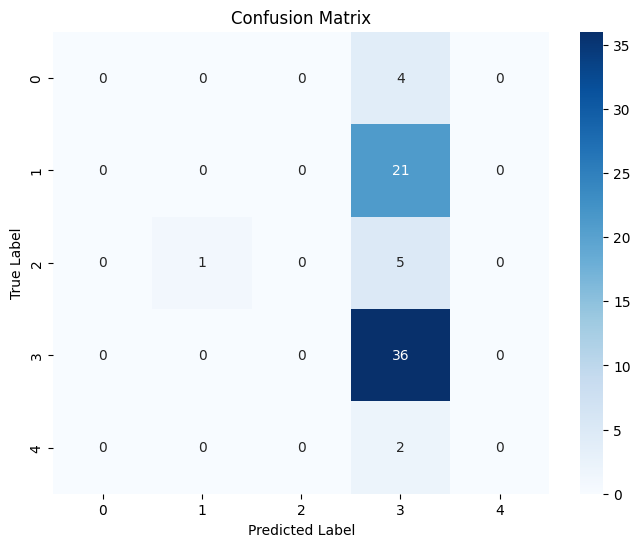

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.00      0.00      0.00        21
           2       0.00      0.00      0.00         6
           3       0.53      1.00      0.69        36
           4       0.00      0.00      0.00         2

    accuracy                           0.52        69
   macro avg       0.11      0.20      0.14        69
weighted avg       0.28      0.52      0.36        69



In [66]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(gt2_missed, gt2_pred))

cm = confusion_matrix(gt2_missed, gt2_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(gt2_missed), yticklabels=np.unique(gt2_missed))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(gt2_missed, gt2_pred, zero_division=0))

# Dataset: Taiwan Credit